# Week 5 — Visualisations
Loads saved evaluation results and generates all five figures:
1. Training curve (loss + F1 over epochs)
2. Per-class F1 bar chart (baseline vs fine-tuned)
3. Confusion matrix (top-N most frequent classes)
4. ROC curves with AUC (one-vs-rest, all 28 classes)
5. Precision-Recall curves (all 28 classes)

Run `eval.ipynb` first to generate the required files in `results/`.

In [1]:
pip install matplotlib seaborn scikit-learn -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
%cd gdrive/My\ Drive/Colab\ Notebooks/emotion_project

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, glob, os
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, average_precision_score

os.makedirs('figures', exist_ok=True)

THRESHOLD  = 0.5
NUM_LABELS = 28
LABEL_NAMES = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
    'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
    'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
    'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
    'relief', 'remorse', 'sadness', 'surprise', 'neutral'
]

# Load eval results
test_labels    = np.load('results/test_labels.npy').astype(int)
baseline_probs = np.load('results/test_probs_baseline.npy')
initial_probs  = np.load('results/test_probs_initial.npy')
freeze3_probs  = np.load('results/test_probs_freeze3.npy')

baseline_pc = pd.read_csv('results/test_per_class_baseline.csv')
initial_pc  = pd.read_csv('results/test_per_class_initial.csv')
freeze3_pc  = pd.read_csv('results/test_per_class_freeze3.csv')

with open('results/test_metrics_baseline.json') as f: baseline_overall = json.load(f)
with open('results/test_metrics_initial.json')  as f: initial_overall  = json.load(f)
with open('results/test_metrics_freeze3.json')  as f: freeze3_overall  = json.load(f)

# Shared model list used by ROC / PR / confusion cells
MODELS = [
    (baseline_probs, 'Baseline',          'steelblue'),
    (initial_probs,  'Initial fine-tune', 'darkorange'),
    (freeze3_probs,  'Freeze-3',          'seagreen'),
]

# Load training history (all saved runs)
run_files = sorted(glob.glob('results/run_*.csv'))
all_runs  = pd.concat([pd.read_csv(f) for f in run_files], ignore_index=True)
print('Loaded runs:', all_runs['run'].unique().tolist())
print('Test labels shape:', test_labels.shape)

Loaded runs: ['freeze6', 'initial']
Test labels shape: (5427, 28)


## 1. Training Curve

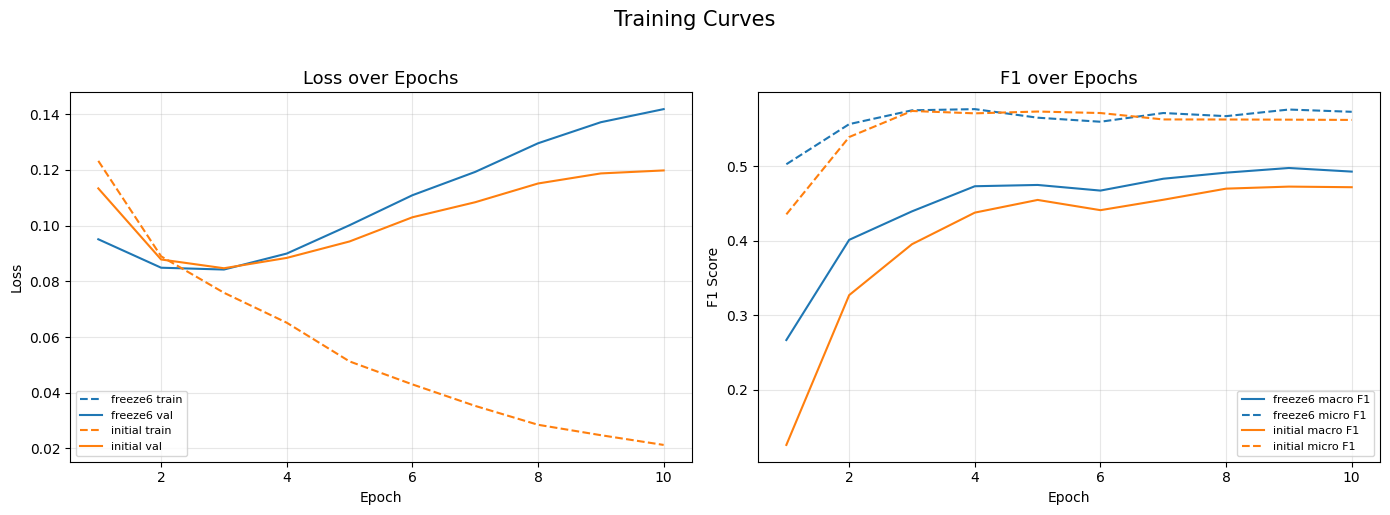

Saved figures/training_curve.png


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for idx, (run_name, group) in enumerate(all_runs.groupby('run')):
    c = colors[idx % len(colors)]
    if 'train_loss' in group.columns:
        axes[0].plot(group['epoch'], group['train_loss'], color=c, linestyle='--',
                     label=f'{run_name} train')
    axes[0].plot(group['epoch'], group['loss'], color=c, linestyle='-',
                 label=f'{run_name} val')
    axes[1].plot(group['epoch'], group['macro_f1'], color=c, linestyle='-',
                 label=f'{run_name} macro F1')
    axes[1].plot(group['epoch'], group['micro_f1'], color=c, linestyle='--',
                 label=f'{run_name} micro F1')

axes[0].set_title('Loss over Epochs', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('F1 over Epochs', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Curves', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('figures/training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/training_curve.png')

## 2. Per-Class F1 Bar Chart

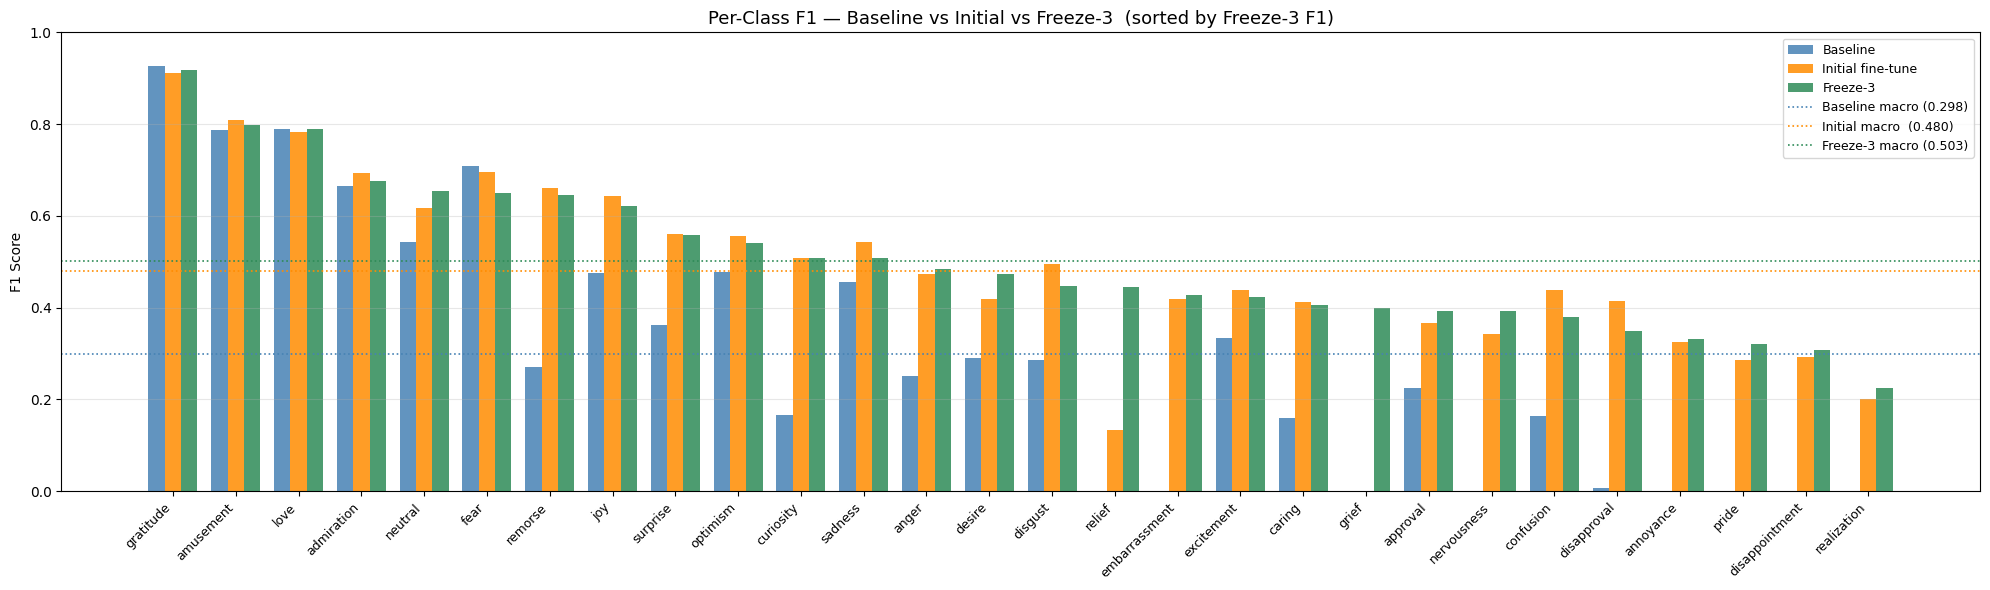

Saved figures/per_class_f1.png


In [3]:
# Sort by Freeze-3 F1 descending
order       = freeze3_pc.sort_values('f1', ascending=False)['label'].tolist()
baseline_f1 = baseline_pc.set_index('label').loc[order, 'f1'].values
initial_f1  = initial_pc.set_index('label').loc[order, 'f1'].values
freeze3_f1  = freeze3_pc.set_index('label').loc[order, 'f1'].values

x = np.arange(NUM_LABELS)
w = 0.26

fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(x - w, baseline_f1, width=w, label='Baseline',          color='steelblue',  alpha=0.85)
ax.bar(x,     initial_f1,  width=w, label='Initial fine-tune', color='darkorange', alpha=0.85)
ax.bar(x + w, freeze3_f1,  width=w, label='Freeze-3',          color='seagreen',   alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1)
ax.set_title('Per-Class F1 — Baseline vs Initial vs Freeze-3  (sorted by Freeze-3 F1)', fontsize=13)
ax.grid(axis='y', alpha=0.3)

ax.axhline(baseline_overall['macro_f1'], color='steelblue',  linestyle=':', lw=1.2)
ax.axhline(initial_overall['macro_f1'],  color='darkorange', linestyle=':', lw=1.2)
ax.axhline(freeze3_overall['macro_f1'],  color='seagreen',   linestyle=':', lw=1.2)

# Combined legend (bars + macro lines)
from matplotlib.lines import Line2D
handles, labels = ax.get_legend_handles_labels()
handles += [
    Line2D([0], [0], color='steelblue',  linestyle=':', lw=1.2, label=f'Baseline macro ({baseline_overall["macro_f1"]:.3f})'),
    Line2D([0], [0], color='darkorange', linestyle=':', lw=1.2, label=f'Initial macro  ({initial_overall["macro_f1"]:.3f})'),
    Line2D([0], [0], color='seagreen',   linestyle=':', lw=1.2, label=f'Freeze-3 macro ({freeze3_overall["macro_f1"]:.3f})'),
]
ax.legend(handles=handles, fontsize=9)

plt.tight_layout()
plt.savefig('figures/per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/per_class_f1.png')

## 3. Confusion Matrix — Top-N Most Frequent Classes

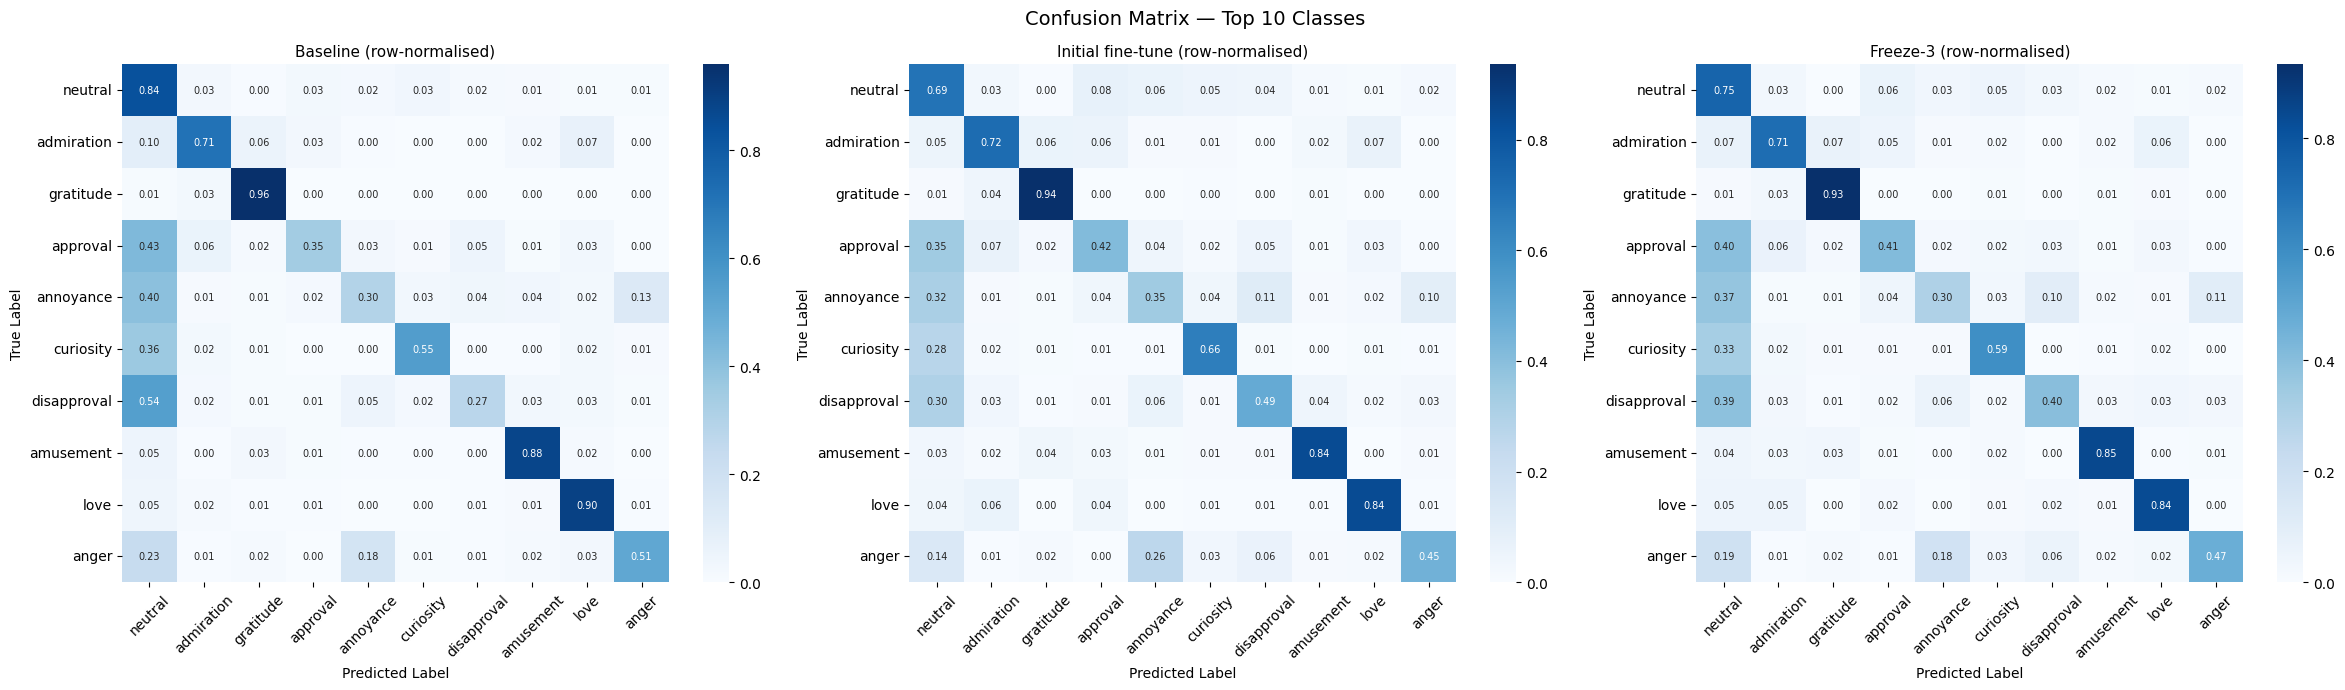

Saved figures/confusion_matrix.png
Top-10 classes by support: ['neutral', 'admiration', 'gratitude', 'approval', 'annoyance', 'curiosity', 'disapproval', 'amusement', 'love', 'anger']


In [4]:
TOP_N = 10

support    = test_labels.sum(axis=0)
topn_idxs  = np.argsort(support)[::-1][:TOP_N]
topn_names = [LABEL_NAMES[i] for i in topn_idxs]
idx_remap  = {old: new for new, old in enumerate(topn_idxs)}

true_primary = np.argmax(test_labels, axis=1)
mask         = np.isin(true_primary, topn_idxs)
true_topn    = np.array([idx_remap[l] for l in true_primary[mask]])

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, (probs, label, _) in zip(axes, MODELS):
    pred_primary = np.argmax(probs, axis=1)
    pred_topn    = np.array([idx_remap.get(p, TOP_N) for p in pred_primary[mask]])
    cm           = confusion_matrix(true_topn, pred_topn, labels=list(range(TOP_N)))
    cm_norm      = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=topn_names, yticklabels=topn_names, ax=ax,
                annot_kws={'size': 7})
    ax.set_title(f'{label} (row-normalised)', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label',      fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle(f'Confusion Matrix — Top {TOP_N} Classes', fontsize=14)
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/confusion_matrix.png')
print(f'Top-{TOP_N} classes by support:', topn_names)

## 4. ROC Curves — All 28 Classes (one-vs-rest)

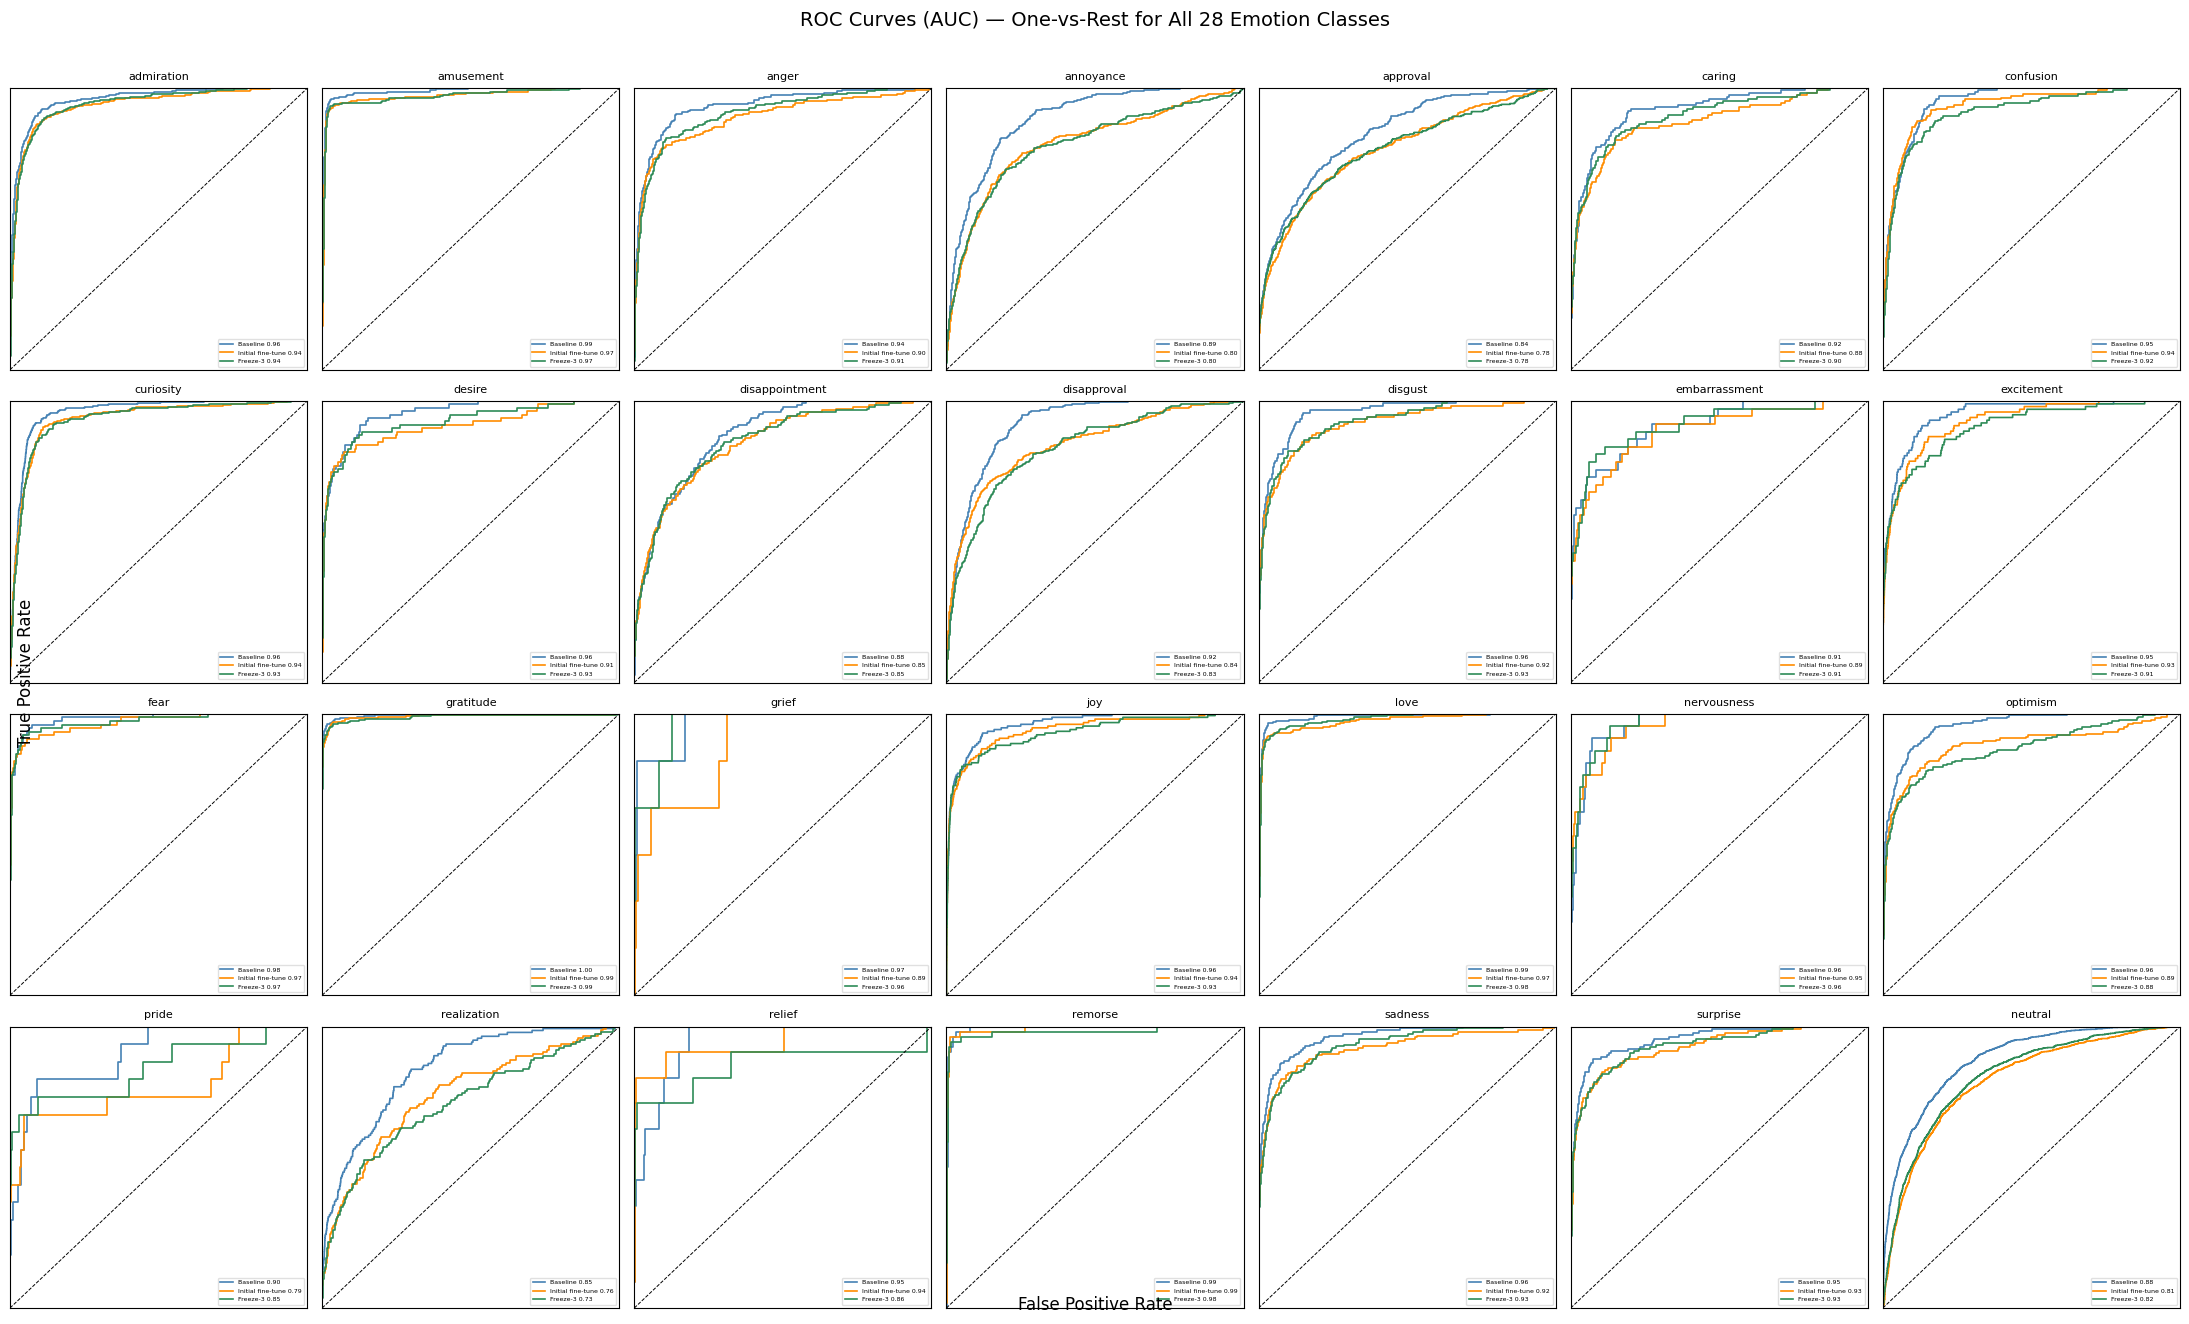

Saved figures/roc_curves.png


In [5]:
NROWS, NCOLS = 4, 7
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(22, 13))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(LABEL_NAMES, axes)):
    if test_labels[:, i].sum() == 0:
        ax.text(0.5, 0.5, 'no positives', ha='center', va='center',
                transform=ax.transAxes, fontsize=7)
        ax.set_title(name, fontsize=8)
        continue

    for probs, label, color in MODELS:
        fpr, tpr, _ = roc_curve(test_labels[:, i], probs[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=1.2, label=f'{label} {roc_auc:.2f}')

    ax.plot([0, 1], [0, 1], 'k--', lw=0.7)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(name, fontsize=8)
    ax.legend(fontsize=4.5, loc='lower right', framealpha=0.6)

fig.text(0.5, 0.01, 'False Positive Rate', ha='center', fontsize=12)
fig.text(0.01, 0.5, 'True Positive Rate',  va='center', rotation='vertical', fontsize=12)
fig.suptitle('ROC Curves (AUC) — One-vs-Rest for All 28 Emotion Classes', fontsize=14, y=1.01)

plt.tight_layout()
plt.savefig('figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/roc_curves.png')

## 5. Precision-Recall Curves — All 28 Classes

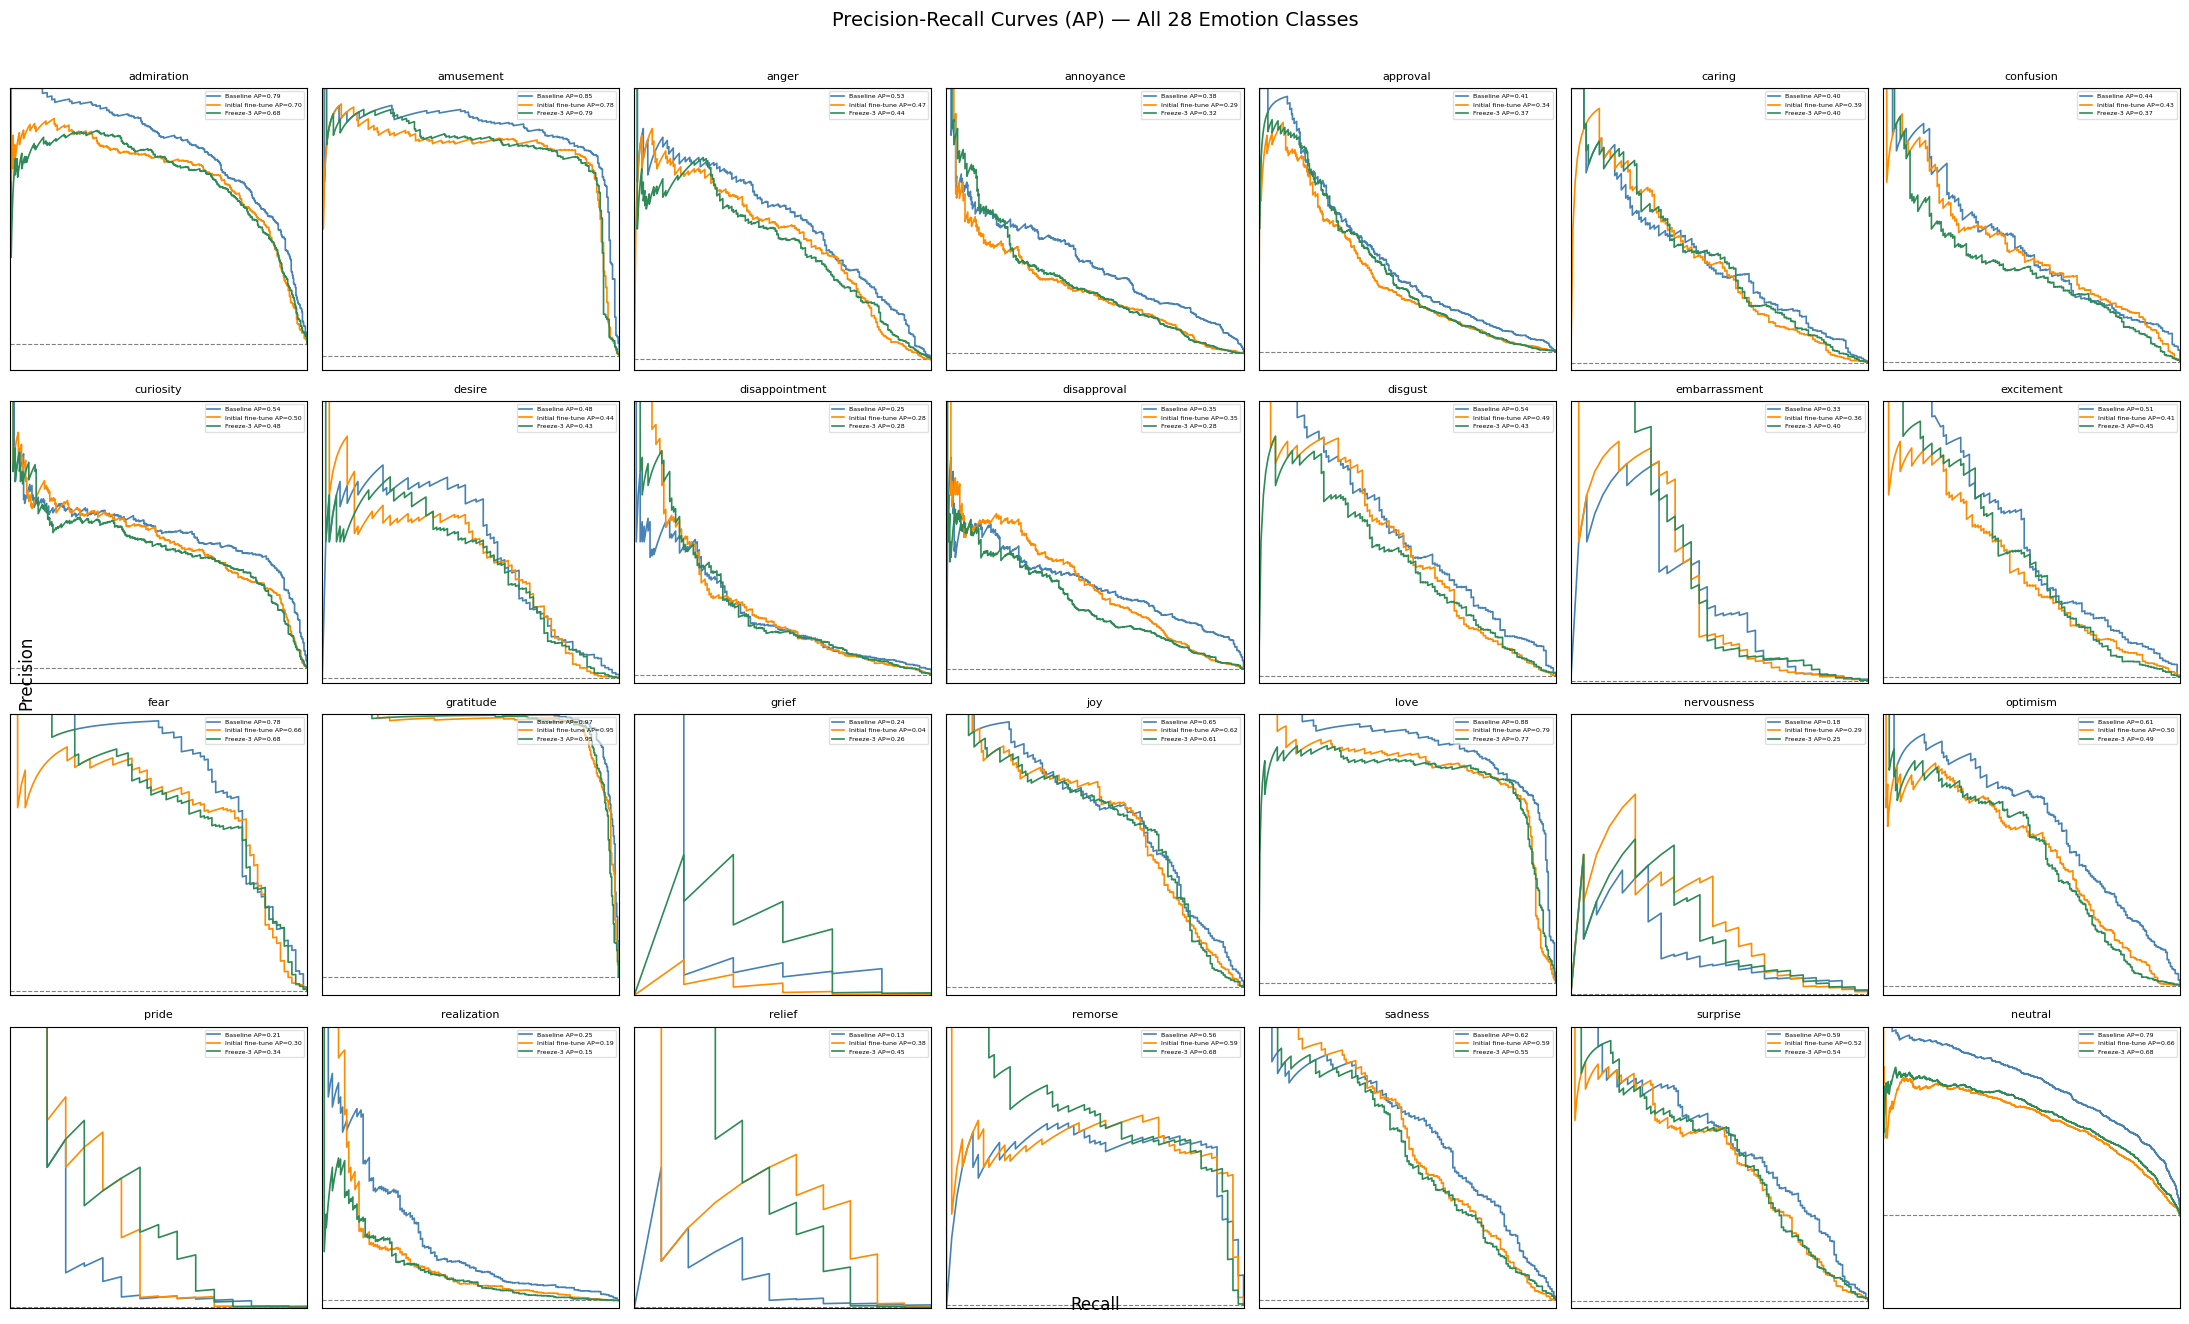

Saved figures/pr_curves.png


In [6]:
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(22, 13))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(LABEL_NAMES, axes)):
    if test_labels[:, i].sum() == 0:
        ax.text(0.5, 0.5, 'no positives', ha='center', va='center',
                transform=ax.transAxes, fontsize=7)
        ax.set_title(name, fontsize=8)
        continue

    chance = test_labels[:, i].mean()
    ax.axhline(chance, color='grey', linestyle='--', lw=0.8)

    for probs, label, color in MODELS:
        precision, recall, _ = precision_recall_curve(test_labels[:, i], probs[:, i])
        ap = average_precision_score(test_labels[:, i], probs[:, i])
        ax.plot(recall, precision, color=color, lw=1.2, label=f'{label} AP={ap:.2f}')

    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(name, fontsize=8)
    ax.legend(fontsize=4.5, loc='upper right', framealpha=0.6)

fig.text(0.5, 0.01, 'Recall',    ha='center', fontsize=12)
fig.text(0.01, 0.5, 'Precision', va='center', rotation='vertical', fontsize=12)
fig.suptitle('Precision-Recall Curves (AP) — All 28 Emotion Classes', fontsize=14, y=1.01)

plt.tight_layout()
plt.savefig('figures/pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/pr_curves.png')

## Summary — figures saved

## 6. Freeze-3 Gains — Labels Where Freeze-3 Outperforms Initial

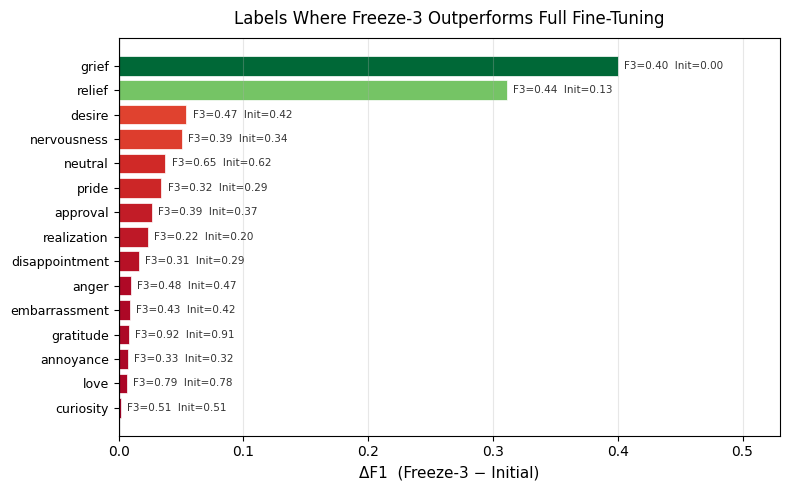

Saved figures/freeze3_gains.png


In [3]:
gains = pd.read_csv('results/freeze3_vs_initial_f1_gains.csv')
gains = gains.sort_values('delta_f1', ascending=True)  # ascending so largest is at top

# Colour bars by delta magnitude
norm = plt.Normalize(gains['delta_f1'].min(), gains['delta_f1'].max())
colors = plt.cm.RdYlGn(norm(gains['delta_f1'].values))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(gains['label'], gains['delta_f1'], color=colors, edgecolor='white', linewidth=0.5)

# Annotate bars with Freeze-3 and Initial F1
for bar, (_, row) in zip(bars, gains.iterrows()):
    ax.text(
        bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
        f"F3={row['freeze3_f1']:.2f}  Init={row['initial_f1']:.2f}",
        va='center', ha='left', fontsize=7.5, color='#333333'
    )

ax.set_xlabel('ΔF1  (Freeze-3 − Initial)', fontsize=11)
ax.set_title('Labels Where Freeze-3 Outperforms Full Fine-Tuning', fontsize=12, pad=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(0, gains['delta_f1'].max() + 0.13)
ax.grid(axis='x', alpha=0.3)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('figures/freeze3_gains.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/freeze3_gains.png')


In [7]:
print('figures/ directory:')
for f in sorted(os.listdir('figures')):
    print(f'  {f}')

figures/ directory:
  confusion_matrix.png
  per_class_f1.png
  pr_curves.png
  roc_curves.png
  training_curve.png
